# Score prediction


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.__version__

'2.1.0'

## Setting Data

3:6 3,4,5 번 열을 읽는다는 뜻이고 엑셀 브레이크 스티어링값
7 7번을 읽는다는 뜻이고 이건 속도
6은 rpm인데 같이 넣으면 학습이 잘 안됨

In [22]:
#xy = np.loadtxt('./dataset_392.csv', delimiter=',', dtype=np.float32)
xy = np.loadtxt('./dataset_200306.csv', delimiter=',', dtype=np.float32)

x_train = xy[0:3453, 0:3]
y_train = xy[0:3453, [3]]

print(x_train.shape, y_train.shape)


(3453, 3) (3453, 1)


## make a dataset

In [23]:
dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(len(x_train))


In [24]:
W = tf.Variable(tf.random.normal([3, 1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')

print(W,b)


<tf.Variable 'weight:0' shape=(3, 1) dtype=float32, numpy=
array([[-0.3500225 ],
       [-0.4288663 ],
       [ 0.83153224]], dtype=float32)> <tf.Variable 'bias:0' shape=(1,) dtype=float32, numpy=array([-2.7028039], dtype=float32)>


In [25]:
def linear_regression(features):
    hypothesis  = tf.matmul(features, W) + b
    return hypothesis
  
print(linear_regression(x_train))

tf.Tensor(
[[-3.4804556]
 [-3.4804556]
 [-3.4804556]
 ...
 [-3.050816 ]
 [-3.050816 ]
 [-3.0514348]], shape=(3453, 1), dtype=float32)


In [26]:
def loss_fn(hypothesis, labels):
    cost = tf.reduce_mean(tf.square(hypothesis - labels))
    return cost

optimizer = tf.compat.v1.train.GradientDescentOptimizer(learning_rate=0.05)
#v392 0.001

In [27]:
epochs = 5000

for step in range(epochs):
  for features, labels in dataset:
    with tf.GradientTape() as tape:
      loss_value = loss_fn(linear_regression(features),labels)
      grads = tape.gradient(loss_value, [W,b])
      optimizer.apply_gradients(grads_and_vars=zip(grads,[W,b]))
      if step % 100 == 0:
            print("Iter: {}, Loss: {:.4f}".format(step, loss_fn(linear_regression(features),labels)))

Iter: 0, Loss: 1867.5978
Iter: 100, Loss: 324.9896
Iter: 200, Loss: 314.6661
Iter: 300, Loss: 311.2282
Iter: 400, Loss: 309.6573
Iter: 500, Loss: 308.8357
Iter: 600, Loss: 308.3862
Iter: 700, Loss: 308.1371
Iter: 800, Loss: 307.9986
Iter: 900, Loss: 307.9214
Iter: 1000, Loss: 307.8784
Iter: 1100, Loss: 307.8545
Iter: 1200, Loss: 307.8410
Iter: 1300, Loss: 307.8336
Iter: 1400, Loss: 307.8295
Iter: 1500, Loss: 307.8271
Iter: 1600, Loss: 307.8259
Iter: 1700, Loss: 307.8253
Iter: 1800, Loss: 307.8248
Iter: 1900, Loss: 307.8245
Iter: 2000, Loss: 307.8245
Iter: 2100, Loss: 307.8243
Iter: 2200, Loss: 307.8242
Iter: 2300, Loss: 307.8242
Iter: 2400, Loss: 307.8242
Iter: 2500, Loss: 307.8242
Iter: 2600, Loss: 307.8242
Iter: 2700, Loss: 307.8243
Iter: 2800, Loss: 307.8242
Iter: 2900, Loss: 307.8242
Iter: 3000, Loss: 307.8242
Iter: 3100, Loss: 307.8243
Iter: 3200, Loss: 307.8242
Iter: 3300, Loss: 307.8242
Iter: 3400, Loss: 307.8242
Iter: 3500, Loss: 307.8242
Iter: 3600, Loss: 307.8242
Iter: 3700, 

In [28]:
print(W, b)

<tf.Variable 'weight:0' shape=(3, 1) dtype=float32, numpy=
array([[ 16.62032  ],
       [  2.8177862],
       [-27.118698 ]], dtype=float32)> <tf.Variable 'bias:0' shape=(1,) dtype=float32, numpy=array([35.967728], dtype=float32)>


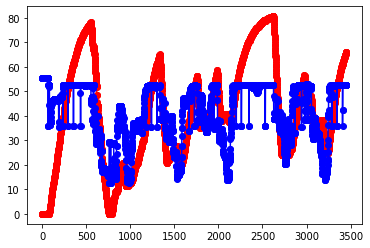

In [29]:
hypothesis= linear_regression(x_train)

plt.plot(y_train, 'o-', color='red')
plt.plot(hypothesis.numpy(), 'o-', color='blue')
plt.show()